# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Import library untuk manipulasi data
import pandas as pd
import numpy as np

# Import library untuk visualisasi data (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk preprocessing dan machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Mengatur tema visualisasi
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Memuat dataset
file_path = 'ronaldo_goals_kaggle_ready.csv'
df = pd.read_csv(file_path)

# Menampilkan 5 baris pertama 
display(df.head())

# Menampilkan informasi dimensi dataset
print(f"Total baris: {df.shape[0]}")
print(f"Total kolom: {df.shape[1]}")

,competition,stage,match_date,home_away,team,opponent,final_score,player_position,goal_minute,score_after_goal,goal_method,assist_player,season,goal_decade,is_home_goal,goal_minute_bucket
0,Liga Portugal,6,07/10/02,Home,Sporting CP,Moreirense FC,3:0,LW,34',2:0,Solo run,Not Applicable,2002/03,2000s,1,31-45
1,Liga Portugal,6,07/10/02,Home,Sporting CP,Moreirense FC,3:0,LW,90'+5,3:0,Header,Rui Jorge,2002/03,2000s,1,76-90
2,Liga Portugal,8,26/10/02,Away,Sporting CP,Boavista FC,1:2,Not Applicable,88',1:2,Right-footed shot,Carlos Martins,2002/03,2000s,0,76-90
3,Taça de Portugal,Fourth Round,24/11/02,Home,Sporting CP,CD Estarreja,4:1,LW,67',3:1,Left-footed shot,César Prates,2002/03,2000s,1,61-75
4,Taça de Portugal,Fifth Round,18/12/02,Home,Sporting CP,FC Oliveira do Hospital,8:1,SS,13',3:0,Left-footed shot,Ricardo Fernandes,2002/03,2000s,1,01-15


Total baris: 816
Total kolom: 16


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   competition         816 non-null    object
 1   stage               816 non-null    object
 2   match_date          816 non-null    object
 3   home_away           816 non-null    object
 4   team                816 non-null    object
 5   opponent            816 non-null    object
 6   final_score         816 non-null    object
 7   player_position     816 non-null    object
 8   goal_minute         816 non-null    object
 9   score_after_goal    816 non-null    object
 10  goal_method         816 non-null    object
 11  assist_player       816 non-null    object
 12  season              816 non-null    object
 13  goal_decade         816 non-null    object
 14  is_home_goal        816 non-null    int64 
 15  goal_minute_bucket  816 non-null    object
dtype

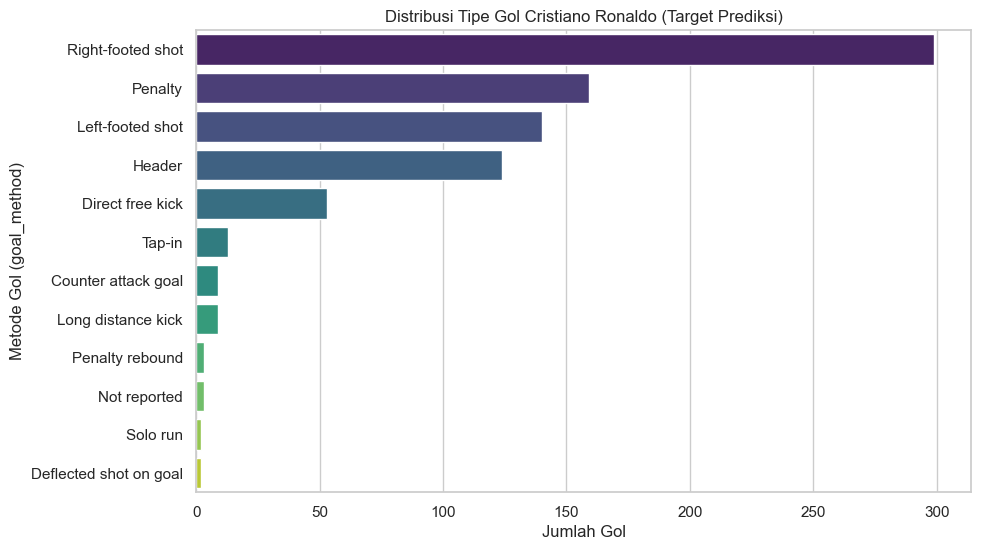

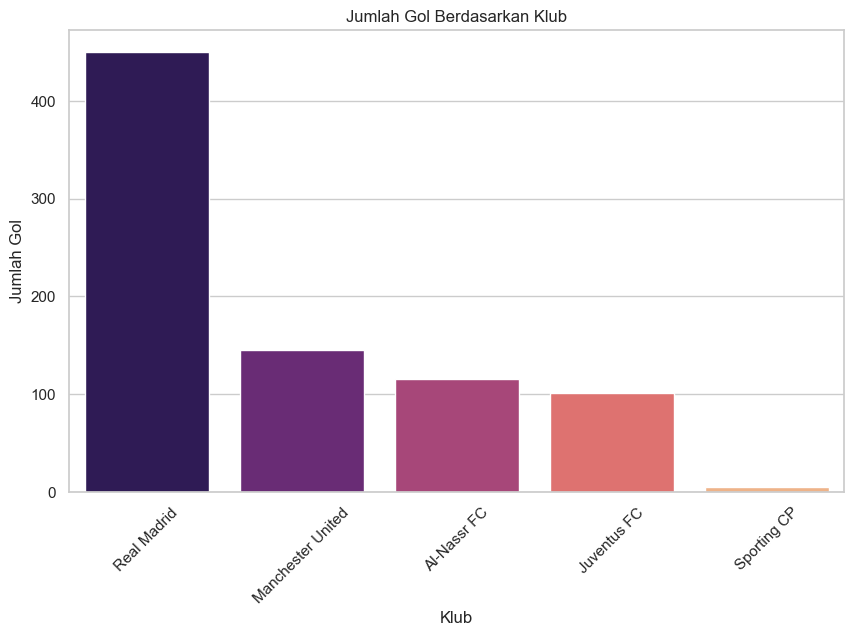

In [3]:
# 1. Cek tipe data dan jumlah nilai kosong (Missing Values)
print("--- Informasi Dataset ---")
df.info()

print("\n--- Jumlah Missing Values ---")
print(df.isnull().sum())

# 2. Visualisasi Distribusi Target Klasifikasi (Tipe Gol / goal_method)
plt.figure(figsize=(10, 6))
sns.countplot(y='goal_method', data=df, order=df['goal_method'].value_counts().index, palette='viridis')
plt.title('Distribusi Tipe Gol Cristiano Ronaldo (Target Prediksi)')
plt.xlabel('Jumlah Gol')
plt.ylabel('Metode Gol (goal_method)')
plt.show()

# 3. Visualisasi Gol Berdasarkan Klub
plt.figure(figsize=(10, 6))
sns.countplot(x='team', data=df, order=df['team'].value_counts().index, palette='magma')
plt.title('Jumlah Gol Berdasarkan Klub')
plt.xlabel('Klub')
plt.ylabel('Jumlah Gol')
plt.xticks(rotation=45)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# Menyalin dataframe agar data asli tidak berubah
df_clean = df.copy()

# Mengisi 'assist_player' yang kosong dengan 'No Assist'
df_clean['assist_player'] = df_clean['assist_player'].fillna('No Assist')

# Hapus missing values bawaan pandas pada target (jika ada)
df_clean.dropna(subset=['goal_method'], inplace=True) 

# HAPUS label 'Not reported' karena tidak berguna untuk model ML
df_clean = df_clean[df_clean['goal_method'] != 'Not reported']

print("Dimensi setelah pembersihan:", df_clean.shape)

Dimensi setelah pembersihan: (813, 16)


In [5]:
# Menghapus kolom yang tidak relevan untuk prediksi
kolom_dihapus = ['match_date', 'final_score', 'score_after_goal']
df_clean.drop(columns=[col for col in kolom_dihapus if col in df_clean.columns], inplace=True)

print("Fitur yang tersisa:", df_clean.columns.tolist())

Fitur yang tersisa: ['competition', 'stage', 'home_away', 'team', 'opponent', 'player_position', 'goal_minute', 'goal_method', 'assist_player', 'season', 'goal_decade', 'is_home_goal', 'goal_minute_bucket']


In [6]:
# Pisahkan fitur (X) dan target (y)
X = df_clean.drop(columns=['goal_method'])
y = df_clean['goal_method']

# Encode target (y)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Mapping Kelas Target:", dict(zip(le.classes_, le.transform(le.classes_))))

# Encode fitur kategorikal (X) dengan One-Hot Encoding
kolom_kategorikal = X.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X, columns=kolom_kategorikal, drop_first=True)
print("\nDimensi X setelah One-Hot Encoding:", X_encoded.shape)

Mapping Kelas Target: {'Counter attack goal': np.int64(0), 'Deflected shot on goal': np.int64(1), 'Direct free kick': np.int64(2), 'Header': np.int64(3), 'Left-footed shot': np.int64(4), 'Long distance kick': np.int64(5), 'Penalty': np.int64(6), 'Penalty rebound': np.int64(7), 'Right-footed shot': np.int64(8), 'Solo run': np.int64(9), 'Tap-in': np.int64(10)}

Dimensi X setelah One-Hot Encoding: (813, 478)


In [7]:
# Standarisasi fitur agar memiliki skala yang sama
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)

# Menampilkan hasil akhir dataset yang siap masuk tahap modeling
print("Dimensi dataset akhir (X_scaled):", X_scaled.shape)
display(X_scaled.head())

Dimensi dataset akhir (X_scaled): (813, 478)


,is_home_goal,competition_Champions League Qu.,competition_Club World Cup,competition_Copa del Rey,competition_EFL Cup,competition_Europa League,competition_FA Cup,competition_Italy Cup,competition_King's Cup,competition_LaLiga,...,season_2024/25,season_2025/26,goal_decade_2010s,goal_decade_2020s,goal_minute_bucket_16-30,goal_minute_bucket_31-45,goal_minute_bucket_46-60,goal_minute_bucket_61-75,goal_minute_bucket_76-90,goal_minute_bucket_90+
0,0.871631,-0.035093,-0.093193,-0.166772,-0.070316,-0.04966,-0.127475,-0.070316,-0.060858,-0.787097,...,-0.212102,-0.162835,-1.191488,-0.574983,-0.420185,2.183107,-0.434277,-0.434277,-0.544657,-0.093193
1,0.871631,-0.035093,-0.093193,-0.166772,-0.070316,-0.04966,-0.127475,-0.070316,-0.060858,-0.787097,...,-0.212102,-0.162835,-1.191488,-0.574983,-0.420185,-0.458063,-0.434277,-0.434277,1.836020,-0.093193
2,-1.147275,-0.035093,-0.093193,-0.166772,-0.070316,-0.04966,-0.127475,-0.070316,-0.060858,-0.787097,...,-0.212102,-0.162835,-1.191488,-0.574983,-0.420185,-0.458063,-0.434277,-0.434277,1.836020,-0.093193
3,0.871631,-0.035093,-0.093193,-0.166772,-0.070316,-0.04966,-0.127475,-0.070316,-0.060858,-0.787097,...,-0.212102,-0.162835,-1.191488,-0.574983,-0.420185,-0.458063,-0.434277,2.302678,-0.544657,-0.093193
4,0.871631,-0.035093,-0.093193,-0.166772,-0.070316,-0.04966,-0.127475,-0.070316,-0.060858,-0.787097,...,-0.212102,-0.162835,-1.191488,-0.574983,-0.420185,-0.458063,-0.434277,-0.434277,-0.544657,-0.093193
